In [126]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [127]:
latshape, lonshape = 84, 48
west, east, south, north = 98, 102, 13, 20
resolution = 12
westindex = (180 + west) * resolution
eastindex = (180 + east) * resolution
southindex = (90 - south) * resolution
northindex = (90 - north) * resolution

root = '/mnt/d/work/H08_20241210/map/out'
path = f'{root}/riv_num_/rivnum.CAMA.bk5'
rivnum = np.fromfile(path, dtype='float32').reshape(latshape, lonshape)

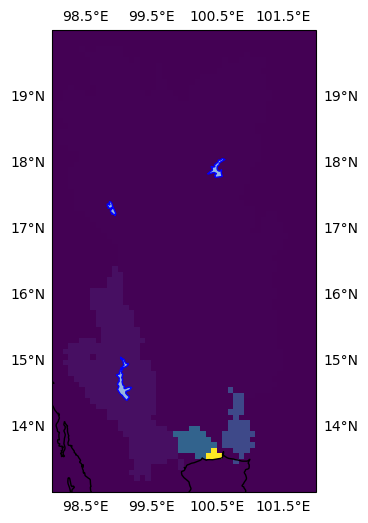

In [129]:
proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(8,6), subplot_kw={'projection': proj})
ax.set_extent([west, east, south, north], crs=proj)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAKES, edgecolor='blue')
ax.imshow(rivnum,
          extent=[west, east, south, north],
          transform=proj)
gl = ax.gridlines(draw_labels=True, linewidth=0)
plt.show()

In [130]:
def plot(img, west=98, east=102, south=13, north=20):
    proj = ccrs.PlateCarree()
    fig, ax = plt.subplots(figsize=(8,6), subplot_kw={'projection': proj})
    ax.set_extent([west, east, south, north], crs=proj)
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.LAKES, edgecolor='blue')
    ax.imshow(img,
              extent=[west, east, south, north],
              transform=proj)
    gl = ax.gridlines(draw_labels=True, linewidth=0)
    plt.show()

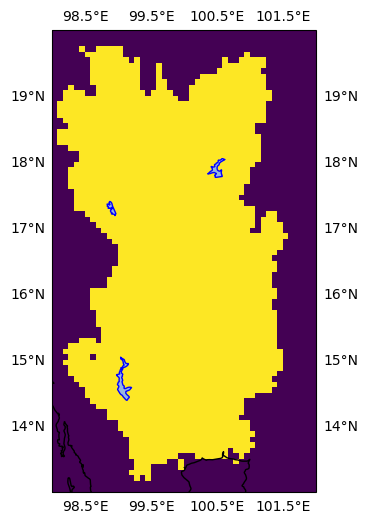

In [131]:
root = '/mnt/d/work/H08_20241210/map/dat'
lndmsk_path = f'{root}/lnd_msk_/lndmsk.CAMA.bk5'
lndmsk = np.fromfile(lndmsk_path, dtype='float32').reshape(latshape, lonshape)
plot(lndmsk)

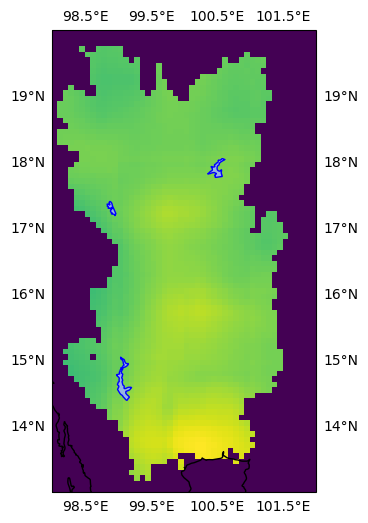

160.543342656 km3/y
117.169319556 km3/y


In [132]:
root = '/mnt/d/work/H08_20241210/lnd/out'
tmp_path = f'{root}/Evap____/W5E5LR__20190000.bk5'
tmp = np.fromfile(tmp_path, dtype='float32').reshape(latshape, lonshape)
plot(tmp)

ara_path = '/mnt/c/Users/tsimk/Downloads/H08_20230612/map/dat/lnd_ara_/lndara.CAMA.bk5'
ara = np.fromfile(ara_path, dtype='float32').reshape(latshape, lonshape)

evap = np.sum(tmp*ara)*86400*365/1e12 #[km3/y]
print(f'{evap} km3/y')

root = '/mnt/c/Users/tsimk/Downloads/H08_20230612/lnd/out'
tmp_path = f'{root}/Evap____/W5E5LR__20190000.bk5'
tmp = np.fromfile(tmp_path, dtype='float32').reshape(latshape, lonshape)
#plot(tmp)

ara_path = '/mnt/c/Users/tsimk/Downloads/H08_20230612/map/dat/lnd_ara_/lndara.CAMA.bk5'
ara = np.fromfile(ara_path, dtype='float32').reshape(latshape, lonshape)

evap = np.sum(tmp*ara)*86400*365/1e12 #[km3/y]
print(f'{evap} km3/y')

In [133]:
name_list = ['LWdown__', 'PSurf___', 'Prcp____', 'Qair____', 'Rainf___', 'SWdown__', 'Snowf___', 'Tair____', 'Wind____']

for name in name_list:
    print(name)
    root = '/mnt/d/work/H08_20241210/met/dat'
    tmp_path = f'{root}/{name}/W5E5____00000000.bk5'
    tmp = np.fromfile(tmp_path, dtype='float32').reshape(latshape, lonshape)
    #plot(tmp)
    
    mask = (lndmsk == 1)
    evap = np.mean(tmp[mask])
    print(f'{evap} km3/y')
    
    root = '/mnt/c/Users/tsimk/Downloads/H08_20230612/met/dat'
    tmp_path = f'{root}/{name}/W5E5____00000000.bk5'
    tmp = np.fromfile(tmp_path, dtype='float32').reshape(latshape, lonshape)
    #plot(tmp)
    
    evap = np.mean(tmp[mask])
    print(f'{evap} km3/y')

LWdown__
401.2986755371094 km3/y
401.2986755371094 km3/y
PSurf___
96867.046875 km3/y
96867.046875 km3/y
Prcp____
5.302320278133266e-05 km3/y
5.302320278133266e-05 km3/y
Qair____
0.01712779700756073 km3/y
0.01712779700756073 km3/y
Rainf___
5.302320278133266e-05 km3/y
5.302320278133266e-05 km3/y
SWdown__
192.7408905029297 km3/y
192.7408905029297 km3/y
Snowf___
9.574771666709739e-14 km3/y
9.574771666709739e-14 km3/y
Tair____
298.98162841796875 km3/y
298.98162841796875 km3/y
Wind____
1.6837047338485718 km3/y
1.6837047338485718 km3/y


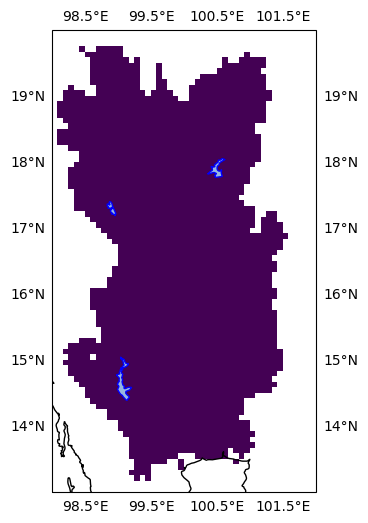

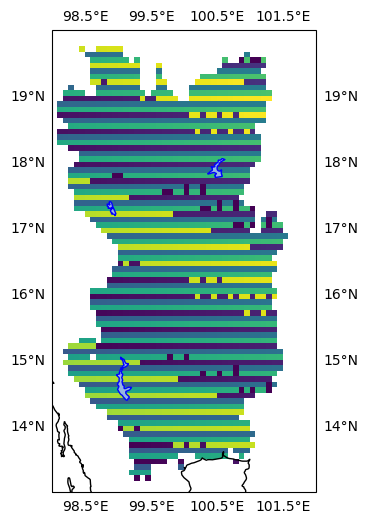

3 5
0.0
0.0


In [134]:
name= 'Snowf___'
day = '09'

root = '/mnt/d/work/H08_20241210/met/dat'
tmp_path = f'{root}/{name}/W5E5____201901{day}.bk5'
tmp = np.fromfile(tmp_path, dtype='float32').reshape(latshape, lonshape)
tmp_cropped_2024 = np.ma.masked_where(lndmsk != 1, tmp)
plot(tmp_cropped_2024)

root = '/mnt/c/Users/tsimk/Downloads/H08_20230612/met/dat'
tmp_path = f'{root}/{name}/W5E5____201901{day}.bk5'
tmp = np.fromfile(tmp_path, dtype='float32').reshape(latshape, lonshape)
tmp_cropped_2023 = np.ma.masked_where(lndmsk != 1, tmp)
plot(tmp_cropped_2023)

def l2xy(lcoordinate, lonlength):
    yindex = lcoordinate // lonlength
    xindex = lcoordinate % lonlength - 1
    return yindex, xindex

ldbg = 150
yindex, xindex = l2xy(ldbg, 48)
print(yindex, xindex)
ldbg_2024 = tmp_cropped_2024[yindex, xindex]
ldbg_2023 = tmp_cropped_2023[yindex, xindex]
print(idebug_2024)
print(idebug_2023)